In [12]:
# %% [markdown]
# # Z. Comparative Analysis: PCA vs. Non-PCA Performance at Optimal Thresholds
# ... (your objective markdown) ...

# %%
# --- Imports for this Section (reuse from previous) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, List , Tuple
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss # For Z.2

# --- Configuration & Data Loading ---
BASE_DIR = Path("/Users/barroca888/Downloads/Agenticfc/AgenticFC888")
NOTEBOOK_OUTPUT_DIR = BASE_DIR / "notebook_outputs" / "L0_focused_model_analysis" # Main output for this notebook
PCA_OUTPUT_SUBDIR = NOTEBOOK_OUTPUT_DIR / "pca" # Specific subdir for PCA related outputs
NONPCA_OUTPUT_SUBDIR = NOTEBOOK_OUTPUT_DIR / "non_pca" # Specific subdir for NonPCA related outputs
COMPARISON_OUTPUT_SUBDIR = NOTEBOOK_OUTPUT_DIR / "comparison_pca_vs_nonpca"
COMPARISON_OUTPUT_SUBDIR.mkdir(parents=True, exist_ok=True)


MATCH_ID_COL = "MatchID"  # Make sure this matches your OOF files
RAW_TARGET_COLS = ['FTHG', 'FTAG', 'FTR'] # From your BaseFeatureConfig

CORE_PROBABILITY_SUFFIXES: List[str] = [ # As defined before
    'prob_H', 'prob_D', 'prob_A', 'prob_1X', 'prob_12', 'prob_X2',
    'prob_O15', 'prob_U15', 'prob_O25', 'prob_U25', 'prob_O35', 'prob_U35', 'prob_O45', 'prob_U45',
    'prob_BTTS_Y', 'prob_BTTS_N',
    'prob_goals_0_1', 'prob_goals_2_3', 'prob_goals_2_4', 'prob_goals_3_plus',
    'prob_H_and_O15', 'prob_D_and_O15', 'prob_A_and_O15', 'prob_H_and_U15', 'prob_D_and_U15', 'prob_A_and_U15',
    'prob_H_and_O25', 'prob_D_and_O25', 'prob_A_and_O25', 'prob_H_and_U25', 'prob_D_and_U25', 'prob_A_and_U25',
    'prob_H_and_O35', 'prob_D_and_O35', 'prob_A_and_O35', 'prob_H_and_U35', 'prob_D_and_U35', 'prob_A_and_U35',
    'prob_H_and_O45', 'prob_D_and_O45', 'prob_A_and_O45', 'prob_H_and_U45', 'prob_D_and_U45', 'prob_A_and_U45',
    'prob_1X_and_O15', 'prob_12_and_O15', 'prob_X2_and_O15', 'prob_1X_and_U15', 'prob_12_and_U15', 'prob_X2_and_U15',
    'prob_1X_and_O25', 'prob_12_and_O25', 'prob_X2_and_O25', 'prob_1X_and_U25', 'prob_12_and_U25', 'prob_X2_and_U25',
    'prob_1X_and_O35', 'prob_12_and_O35', 'prob_X2_and_O35', 'prob_1X_and_U35', 'prob_12_and_U35', 'prob_X2_and_U35',
    'prob_1X_and_O45', 'prob_12_and_O45', 'prob_X2_and_O45', 'prob_1X_and_U45', 'prob_12_and_U45', 'prob_X2_and_U45',
    'prob_H_and_BTTS_Y', 'prob_D_and_BTTS_Y', 'prob_A_and_BTTS_Y',
    'prob_H_and_BTTS_N', 'prob_D_and_BTTS_N', 'prob_A_and_BTTS_N',
    'prob_1X_and_BTTS_Y', 'prob_12_and_BTTS_Y', 'prob_X2_and_BTTS_Y',
    'prob_1X_and_BTTS_N', 'prob_12_and_BTTS_N', 'prob_X2_and_BTTS_N',
    'prob_O25_and_BTTS_Y', 'prob_O25_and_BTTS_N',
    'prob_O35_and_BTTS_Y', 'prob_O35_and_BTTS_N',
]

# --- Helper Function to Derive Actual Outcomes (MUST BE DEFINED AND CORRECT) ---
# (This function needs to be robust and cover all CORE_PROBABILITY_SUFFIXES)
def derive_actual_market_outcomes(df: pd.DataFrame, prob_suffixes: List[str], fthg_col: str, ftag_col: str, ftr_col: str) -> pd.DataFrame:
    """
    Derives binary (0/1) actual outcomes for a list of market probability suffixes.
    """
    df_out = df.copy()
    for suffix in prob_suffixes:
        actual_col_name = f"actual_{suffix.replace('prob_', '')}"
        
        # Single Outcomes
        if suffix == 'prob_H': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'H').astype(int)
        elif suffix == 'prob_D': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'D').astype(int)
        elif suffix == 'prob_A': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'A').astype(int)
        elif suffix == 'prob_1X': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'D')).astype(int)
        elif suffix == 'prob_12': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'A')).astype(int)
        elif suffix == 'prob_X2': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'D') | (df_out[ftr_col] == 'A')).astype(int)
        elif suffix == 'prob_BTTS_Y': 
            df_out[actual_col_name] = ((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0)).astype(int)
        elif suffix == 'prob_BTTS_N': 
            df_out[actual_col_name] = (~((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0))).astype(int)
        # Over/Under (add all relevant lines, e.g. O05, U05, O45, U45 if in CORE_PROBABILITY_SUFFIXES)
        elif suffix == 'prob_O15': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 1.5).astype(int)
        elif suffix == 'prob_U15': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 1.5).astype(int)
        elif suffix == 'prob_O25': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 2.5).astype(int)
        elif suffix == 'prob_U25': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 2.5).astype(int)
        elif suffix == 'prob_O35': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 3.5).astype(int)
        elif suffix == 'prob_U35': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 3.5).astype(int)
        elif suffix == 'prob_O45': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 4.5).astype(int)
        elif suffix == 'prob_U45': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 4.5).astype(int)
        # Goal Bands
        elif suffix == 'prob_goals_0_1': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=0) & (df_out[fthg_col] + df_out[ftag_col] <=1)).astype(int)
        elif suffix == 'prob_goals_2_3': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=2) & (df_out[fthg_col] + df_out[ftag_col] <=3)).astype(int)
        elif suffix == 'prob_goals_2_4': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=2) & (df_out[fthg_col] + df_out[ftag_col] <=4)).astype(int)
        elif suffix == 'prob_goals_3_plus': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 2.5).astype(int) # Same as O2.5
        
        # Combo Bets (Example for H_and_O25, expand for all in CORE_PROBABILITY_SUFFIXES)
        # This requires careful parsing of the suffix string
        elif '_and_' in suffix:
            parts = suffix.replace('prob_', '').split('_and_')
            market1_str, market2_str = parts[0], parts[1]
            
            # Determine outcome for market1
            outcome1 = pd.Series(False, index=df_out.index)
            if market1_str == 'H': 
                outcome1 = df_out[ftr_col] == 'H'
            elif market1_str == 'D': 
                outcome1 = df_out[ftr_col] == 'D'
            elif market1_str == 'A': 
                outcome1 = df_out[ftr_col] == 'A'
            elif market1_str == '1X': 
                outcome1 = (df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'D')
            elif market1_str == '12': 
                outcome1 = (df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'A')
            elif market1_str == 'X2': 
                outcome1 = (df_out[ftr_col] == 'D') | (df_out[ftr_col] == 'A')
            elif market1_str == 'O15': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 1.5
            elif market1_str == 'U15': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 1.5
            elif market1_str == 'O25': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 2.5
            elif market1_str == 'U25': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 2.5
            elif market1_str == 'O35': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 3.5
            elif market1_str == 'U35': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 3.5
            elif market1_str == 'O45': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 4.5
            elif market1_str == 'U45': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 4.5

            # Determine outcome for market2
            outcome2 = pd.Series(False, index=df_out.index)
            if market2_str == 'O15': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 1.5
            elif market2_str == 'U15': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 1.5
            elif market2_str == 'O25': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 2.5
            elif market2_str == 'U25': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 2.5
            elif market2_str == 'O35': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 3.5
            elif market2_str == 'U35': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 3.5
            elif market2_str == 'O45': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 4.5
            elif market2_str == 'U45': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 4.5
            elif market2_str == 'BTTS_Y': 
                outcome2 = (df_out[fthg_col] > 0) & (df_out[ftag_col] > 0)
            elif market2_str == 'BTTS_N': 
                outcome2 = ~((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0))

            df_out[actual_col_name] = (outcome1 & outcome2).astype(int)
        else:
            print(f"Warning: No logic to derive actual outcome for market suffix: {suffix}")
            df_out[actual_col_name] = np.nan # Mark as not derivable for now
            
    return df_out


# --- Load the OOT Summary DataFrames for PCA and Non-PCA ---
PATH_OOT_PCA_CSV = PCA_OUTPUT_SUBDIR / "final_best_oot_selections.csv"
PATH_OOT_NONPCA_CSV = NONPCA_OUTPUT_SUBDIR / "final_best_oot_selections.csv"

final_oot_selections_pca_df = pd.DataFrame()
if PATH_OOT_PCA_CSV.exists():
    final_oot_selections_pca_df = pd.read_csv(PATH_OOT_PCA_CSV)
    print(f"Loaded PCA OOT selections: {final_oot_selections_pca_df.shape}")
else:
    print(f"WARNING: PCA OOT selections CSV not found at {PATH_OOT_PCA_CSV}. Some comparisons might fail.")

final_oot_selections_nonpca_df = pd.DataFrame()
if PATH_OOT_NONPCA_CSV.exists():
    final_oot_selections_nonpca_df = pd.read_csv(PATH_OOT_NONPCA_CSV)
    print(f"Loaded Non-PCA OOT selections: {final_oot_selections_nonpca_df.shape}")
else:
    print(f"WARNING: Non-PCA OOT selections CSV not found at {PATH_OOT_NONPCA_CSV}. Some comparisons might fail.")

# --- Load the full OOF DataFrames for PCA and Non-PCA ---
# Define file paths for both PCA and Non-PCA OOF files
OOF_PCA_FILE_PATH = BASE_DIR / "models/data/outputs/predictions/level0_oof_predictions_pca_L0_focused_without_odds.parquet"
OOF_NONPCA_FILE_PATH = BASE_DIR / "models/data/outputs/level0_oof_predictions_nonpca_L0_focused_without_odds.parquet"

# Print file paths for debugging
print(f"Looking for PCA OOF file at: {OOF_PCA_FILE_PATH}")
print(f"Looking for Non-PCA OOF file at: {OOF_NONPCA_FILE_PATH}")

# Try alternative paths if the original paths don't exist
if not OOF_PCA_FILE_PATH.exists():
    alternative_pca_path = BASE_DIR / "models/data/outputs/level0_oof_predictions_pca_L0_focused_without_odds.parquet"
    if alternative_pca_path.exists():
        OOF_PCA_FILE_PATH = alternative_pca_path
        print(f"Using alternative PCA OOF path: {OOF_PCA_FILE_PATH}")

if not OOF_NONPCA_FILE_PATH.exists():
    alternative_nonpca_path = BASE_DIR / "models/data/outputs/level0_oof_predictions_nonpca_L0_focused_without_odds.parquet"
    if alternative_nonpca_path.exists():
        OOF_NONPCA_FILE_PATH = alternative_nonpca_path
        print(f"Using alternative Non-PCA OOF path: {OOF_NONPCA_FILE_PATH}")

oof_pca_df_with_actuals = pd.DataFrame()
if OOF_PCA_FILE_PATH.exists():
    print(f"Loading full PCA OOF from {OOF_PCA_FILE_PATH}...")
    oof_pca_df_with_actuals = pd.read_parquet(OOF_PCA_FILE_PATH)
    # CRITICAL: Derive actuals if not already in the file
    if not any(col.startswith('actual_') for col in oof_pca_df_with_actuals.columns):
        print("Deriving actual outcomes for PCA OOF data...")
        oof_pca_df_with_actuals = derive_actual_market_outcomes(oof_pca_df_with_actuals, CORE_PROBABILITY_SUFFIXES, RAW_TARGET_COLS[0], RAW_TARGET_COLS[1], RAW_TARGET_COLS[2])
    print(f"PCA OOF with actuals loaded: {oof_pca_df_with_actuals.shape}")
else:
    print(f"CRITICAL WARNING: PCA OOF file not found at {OOF_PCA_FILE_PATH}. Section Z will not work correctly.")

oof_nonpca_df_with_actuals = pd.DataFrame()
if OOF_NONPCA_FILE_PATH.exists():
    print(f"Loading full Non-PCA OOF from {OOF_NONPCA_FILE_PATH}...")
    oof_nonpca_df_with_actuals = pd.read_parquet(OOF_NONPCA_FILE_PATH)
    # CRITICAL: Derive actuals
    if not any(col.startswith('actual_') for col in oof_nonpca_df_with_actuals.columns):
        print("Deriving actual outcomes for Non-PCA OOF data...")
        oof_nonpca_df_with_actuals = derive_actual_market_outcomes(oof_nonpca_df_with_actuals, CORE_PROBABILITY_SUFFIXES, RAW_TARGET_COLS[0], RAW_TARGET_COLS[1], RAW_TARGET_COLS[2])
    print(f"Non-PCA OOF with actuals loaded: {oof_nonpca_df_with_actuals.shape}")
else:
    print(f"CRITICAL WARNING: Non-PCA OOF file not found at {OOF_NONPCA_FILE_PATH}. Section Z will not work correctly.")

print("Setup for PCA vs. Non-PCA Comparison Complete.")

Loaded PCA OOT selections: (22, 8)
Loaded Non-PCA OOT selections: (22, 8)
Looking for PCA OOF file at: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/predictions/level0_oof_predictions_pca_L0_focused_without_odds.parquet
Looking for Non-PCA OOF file at: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/level0_oof_predictions_nonpca_L0_focused_without_odds.parquet
Using alternative PCA OOF path: /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/level0_oof_predictions_pca_L0_focused_without_odds.parquet
Loading full PCA OOF from /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/level0_oof_predictions_pca_L0_focused_without_odds.parquet...
Deriving actual outcomes for PCA OOF data...
PCA OOF with actuals loaded: (109761, 339)
Loading full Non-PCA OOF from /Users/barroca888/Downloads/Agenticfc/AgenticFC888/models/data/outputs/level0_oof_predictions_nonpca_L0_focused_without_odds.parquet...
Deriving actua

In [13]:
# %% [markdown]
# ### Z.2. Performance Analysis *Below* OOTs (Non-Optimal Regions)
#
# For markets where both PCA and Non-PCA have identified OOTs, let's look at the performance *below* those respective OOTs.
# This can tell us if one approach is generally "safer" or less prone to bad losses when predictions aren't "elite."

# %%
# --- Function to get performance below a given threshold for a specific model-market ---
# (Ensure get_performance_below_threshold function is defined here - copy from my previous answer)
def get_performance_below_threshold(
    oof_data_with_actuals: pd.DataFrame, 
    model_prefix: str,
    market_prob_suffix: str, # e.g. "prob_H"
    oot_value: float, 
    min_samples_below: int = 50
) -> Optional[Dict[str, Any]]:
    # Ensure MATCH_ID_COL is defined
    prob_col = f"{model_prefix}_{market_prob_suffix.replace('prob_', '')}"
    actual_col = f"actual_{market_prob_suffix.replace('prob_', '')}"

    if prob_col not in oof_data_with_actuals.columns or actual_col not in oof_data_with_actuals.columns:
        print(f"Warning: Columns missing for below-OOT analysis: {prob_col} or {actual_col}")
        return None

    below_oot_data = oof_data_with_actuals[
        (oof_data_with_actuals[prob_col] < oot_value) &
        pd.notna(oof_data_with_actuals[prob_col]) &
        pd.notna(oof_data_with_actuals[actual_col])
    ].copy() # Use .copy()

    if len(below_oot_data) < min_samples_below:
        return None

    return {
        'model': model_prefix, # This will be the full model name like 'gradient_boosting_pca_without_odds'
        'market_suffix': market_prob_suffix,
        'threshold_used_for_below': oot_value,
        'num_bets_below_oot': len(below_oot_data),
        'wr_below_oot_pct': below_oot_data[actual_col].mean() * 100,
        'avg_pred_prob_below_oot': below_oot_data[prob_col].mean()
    }

# --- Collect below-OOT performance ---
below_oot_performance_list = []

if 'comparison_table_sorted' in locals() and not comparison_table_sorted.empty and \
   not oof_pca_df_with_actuals.empty and not oof_nonpca_df_with_actuals.empty:

    # Iterate through markets present in the comparison table
    for _, row in comparison_table_sorted.iterrows():
        market_s = row['market_suffix']
        
        # PCA below OOT
        model_pca_name = row.get('BestModel_PCA') # Use .get for safety
        oot_pca_val = row.get('OOT_PCA')
        if pd.notna(model_pca_name) and pd.notna(oot_pca_val):
            res_pca = get_performance_below_threshold(oof_pca_df_with_actuals, model_pca_name, market_s, oot_pca_val)
            if res_pca:
                res_pca['data_type'] = 'PCA'
                below_oot_performance_list.append(res_pca)
        
        # Non-PCA below OOT
        model_nonpca_name = row.get('BestModel_NonPCA')
        oot_nonpca_val = row.get('OOT_NonPCA')
        if pd.notna(model_nonpca_name) and pd.notna(oot_nonpca_val):
            res_nonpca = get_performance_below_threshold(oof_nonpca_df_with_actuals, model_nonpca_name, market_s, oot_nonpca_val)
            if res_nonpca:
                res_nonpca['data_type'] = 'NonPCA'
                below_oot_performance_list.append(res_nonpca)

if below_oot_performance_list:
    below_oot_perf_df = pd.DataFrame(below_oot_performance_list)
    print("\n\n--- Performance *Below* Identified OOTs ---")
    display(below_oot_perf_df.sort_values(by=['market_suffix', 'data_type']))
    below_oot_perf_df.to_csv(COMPARISON_OUTPUT_SUBDIR / "below_oot_performance_comparison.csv", index=False)

    if not below_oot_perf_df.empty and \
       all(c in below_oot_perf_df.columns for c in ['market_suffix', 'data_type', 'num_bets_below_oot', 'wr_below_oot_pct']):
        try:
            below_oot_pivot = below_oot_perf_df.pivot_table(
                index=['market_suffix', 'threshold_used_for_below'], # Threshold might differ for PCA/NonPCA for same market
                columns='data_type',
                values=['num_bets_below_oot', 'wr_below_oot_pct']
            )
            display(HTML("<h3>Pivoted Comparison of Performance Below OOTs:</h3>"))
            display(below_oot_pivot)
        except Exception as e:
            print(f"Could not create pivot table for below-OOT performance: {e}")
            print("Displaying raw below_oot_perf_df instead:")
            display(below_oot_perf_df)
    else:
        print("Not enough columns in below_oot_perf_df for pivot table.")
else:
    print("Not enough data to compare performance below OOTs for selected markets.")

Not enough data to compare performance below OOTs for selected markets.


In [14]:
# ### Z.2. Performance Analysis *Below* OOTs (Non-Optimal Regions)
#
# For markets where both PCA and Non-PCA have identified OOTs (in `comparison_table_sorted`),
# let's look at the performance *below* those respective OOTs.
# This can tell us if one approach is generally "safer" or less prone to bad losses
# when predictions aren't "elite."

# %%
# --- Corrected Function to get performance below a given threshold ---
def get_performance_below_threshold(
    oof_data_with_actuals: pd.DataFrame,
    full_model_prefix: str, # This is the complete model name like "gradient_boosting_pca_without_odds"
    market_prob_suffix: str, # This is like "prob_H", "prob_O15" (already includes "prob_")
    oot_value: float,
    min_samples_below: int = 50 # Use constant MIN_SAMPLES_FOR_BIN or a specific one for this analysis
) -> Optional[Dict[str, Any]]:

    prob_col = f"{full_model_prefix}_{market_prob_suffix}" # CORRECTED: Direct concatenation
    actual_col_base_market_name = market_prob_suffix.replace('prob_', '')
    actual_col = f"actual_{actual_col_base_market_name}"

    if prob_col not in oof_data_with_actuals.columns:
        print(f"Warning (get_performance_below_threshold): Probability column '{prob_col}' not found. Skipping.")
        return None
    if actual_col not in oof_data_with_actuals.columns:
        print(f"Warning (get_performance_below_threshold): Actual column '{actual_col}' for market '{market_prob_suffix}' not found. Skipping.")
        return None

    below_oot_data = oof_data_with_actuals[
        (oof_data_with_actuals[prob_col] < oot_value) &
        pd.notna(oof_data_with_actuals[prob_col]) &
        pd.notna(oof_data_with_actuals[actual_col])
    ].copy()

    if len(below_oot_data) < min_samples_below:
        # print(f"Info: Not enough samples ({len(below_oot_data)} < {min_samples_below}) below OOT {oot_value:.3f} for {prob_col}. Skipping.")
        return None

    return {
        'model_full_name': full_model_prefix, # Store the full model name for clarity
        'market_suffix': market_prob_suffix,
        'data_type_inferred': 'PCA' if '_pca_' in full_model_prefix else ('NonPCA' if '_nonpca_' in full_model_prefix else 'Unknown'),
        'oot_threshold_compared_against': oot_value,
        'num_bets_below_oot': len(below_oot_data),
        'wr_below_oot_pct': below_oot_data[actual_col].mean() * 100,
        'avg_pred_prob_below_oot': below_oot_data[prob_col].mean()
    }

# --- Collect below-OOT performance ---
below_oot_performance_list = []

# Ensure necessary DataFrames are loaded and populated from previous cells
if 'comparison_table_sorted' in locals() and not comparison_table_sorted.empty and \
   'oof_pca_df_with_actuals' in locals() and not oof_pca_df_with_actuals.empty and \
   'oof_nonpca_df_with_actuals' in locals() and not oof_nonpca_df_with_actuals.empty:

    print("\n--- Calculating Performance *Below* Identified OOTs ---")
    # Iterate through markets present in the comparison table that have OOTs for both PCA and NonPCA
    for _, row in comparison_table_sorted.dropna(subset=['OOT_PCA', 'OOT_NonPCA', 'BestModel_PCA', 'BestModel_NonPCA']).iterrows():
        market_s = row['market_suffix'] # This is already 'prob_MARKET'

        # PCA below OOT
        model_pca_name = row['BestModel_PCA']
        oot_pca_val = row['OOT_PCA']
        # print(f"Debug PCA: Market={market_s}, Model={model_pca_name}, OOT={oot_pca_val}")
        res_pca = get_performance_below_threshold(oof_pca_df_with_actuals, model_pca_name, market_s, oot_pca_val, min_samples_below=MIN_SAMPLES_FOR_BIN) # Use MIN_SAMPLES_FOR_BIN
        if res_pca:
            # res_pca['data_type'] = 'PCA' # Already inferred in function
            below_oot_performance_list.append(res_pca)

        # Non-PCA below OOT
        model_nonpca_name = row['BestModel_NonPCA']
        oot_nonpca_val = row['OOT_NonPCA']
        # print(f"Debug NonPCA: Market={market_s}, Model={model_nonpca_name}, OOT={oot_nonpca_val}")
        res_nonpca = get_performance_below_threshold(oof_nonpca_df_with_actuals, model_nonpca_name, market_s, oot_nonpca_val, min_samples_below=MIN_SAMPLES_FOR_BIN)
        if res_nonpca:
            # res_nonpca['data_type'] = 'NonPCA' # Already inferred
            below_oot_performance_list.append(res_nonpca)

    if below_oot_performance_list:
        below_oot_perf_df = pd.DataFrame(below_oot_performance_list)
        print("\n--- Summary of Performance *Below* Identified OOTs (Sample) ---")
        display(below_oot_perf_df.sort_values(by=['market_suffix', 'data_type_inferred']).head())
        below_oot_perf_df.to_csv(COMPARISON_OUTPUT_SUBDIR / "below_oot_performance_comparison.csv", index=False)

        # Pivot for easier comparison if data exists
        if not below_oot_perf_df.empty and \
           all(c in below_oot_perf_df.columns for c in ['market_suffix', 'data_type_inferred', 'num_bets_below_oot', 'wr_below_oot_pct']):
            try:
                below_oot_pivot = below_oot_perf_df.pivot_table(
                    index=['market_suffix', 'oot_threshold_compared_against'], # Use actual OOT value in index
                    columns='data_type_inferred',
                    values=['num_bets_below_oot', 'wr_below_oot_pct'],
                    aggfunc='first' # Since each row is unique for data_type_inferred
                )
                display(HTML("<h3>Pivoted Comparison of Performance Below OOTs:</h3>"))
                display(below_oot_pivot.sort_index())
            except Exception as e:
                print(f"Could not create pivot table for below-OOT performance: {e}")
                print("Displaying raw below_oot_perf_df instead:")
                display(below_oot_perf_df.sort_values(by=['market_suffix', 'data_type_inferred']))
        else:
            print("Not enough columns or data in below_oot_perf_df for pivot table.")
    else:
        print("\nNot enough data to compare performance below OOTs for any selected markets (after applying min_samples_below).")
else:
    print("Prerequisite DataFrames for Section Z.2 are missing or empty.")


Prerequisite DataFrames for Section Z.2 are missing or empty.


Loaded master binned performance for PCA models: (2545, 7)
Loaded master binned performance for NonPCA models: (2545, 7)
Combined binned performance data shape: (5090, 8)

--- Generating Visual Comparison Plots for markets: ['prob_H', 'prob_O25', 'prob_U25', 'prob_BTTS_Y', 'prob_1X', 'prob_12', 'prob_U45'] ---
Saved plot: model_perf_comp_H.png


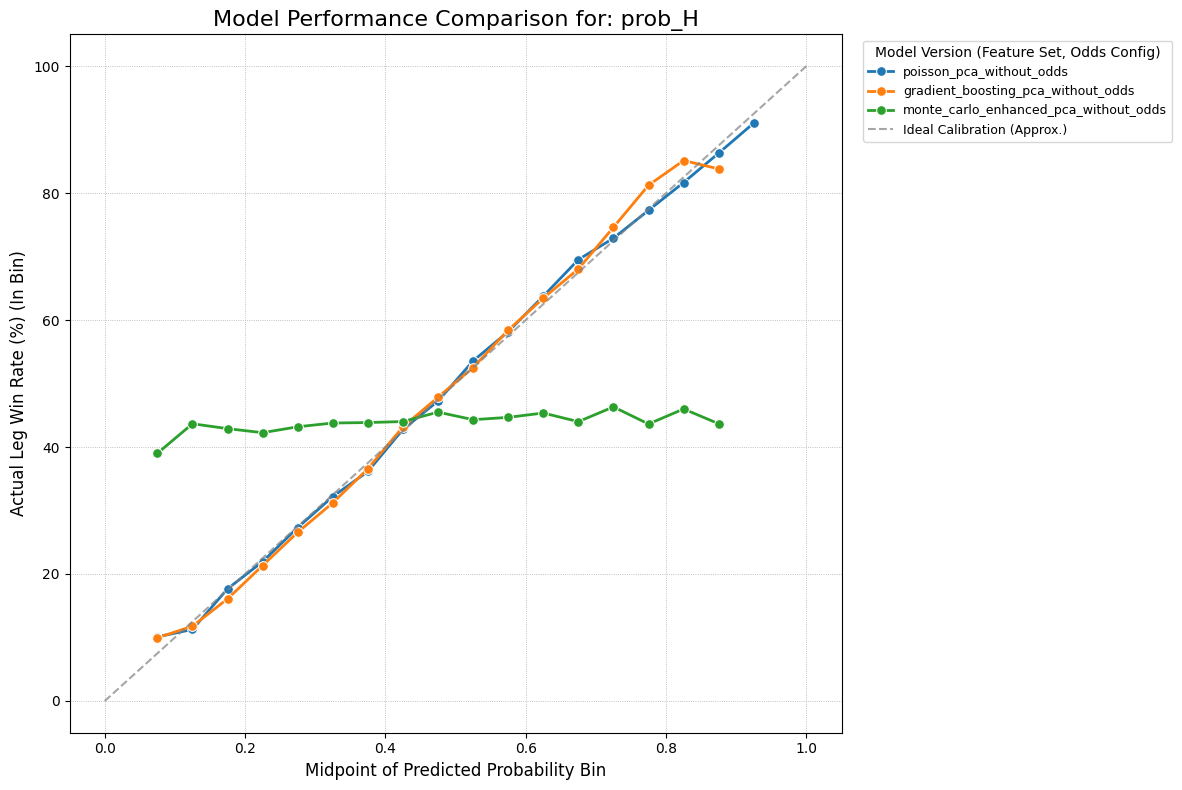

Saved plot: model_perf_comp_O25.png


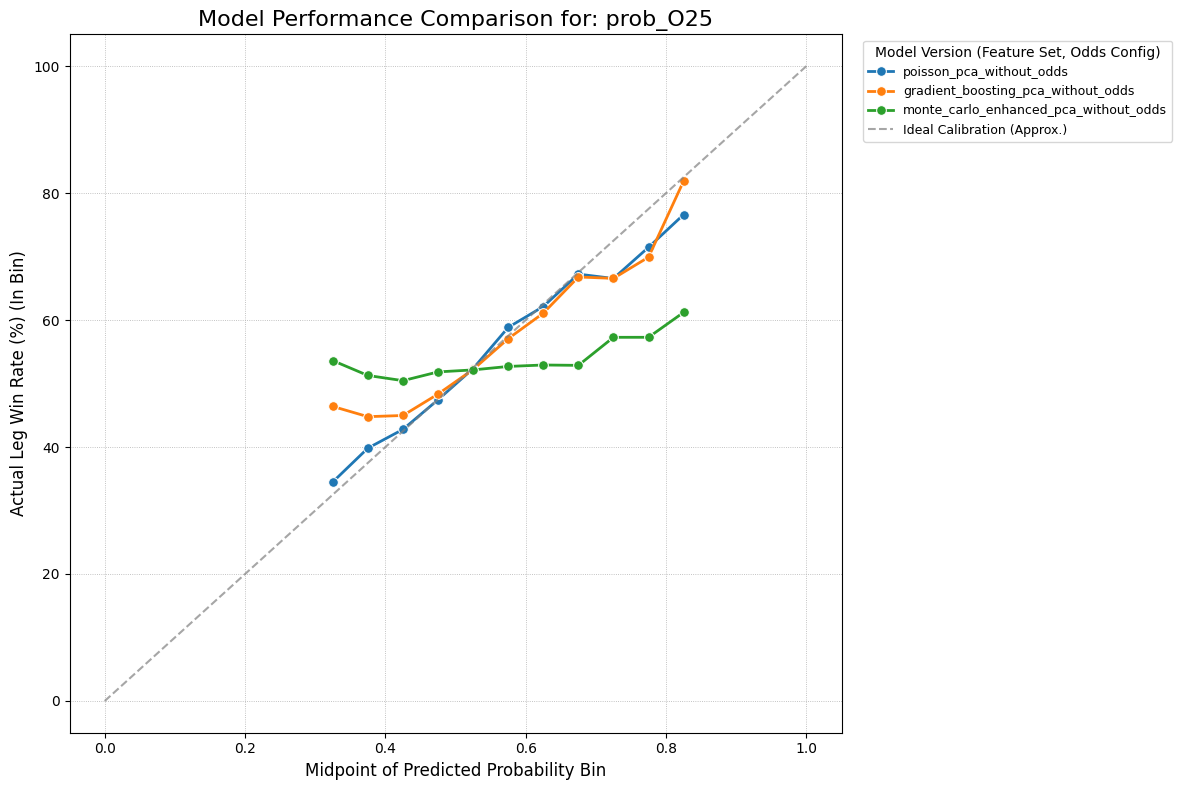

Saved plot: model_perf_comp_U25.png


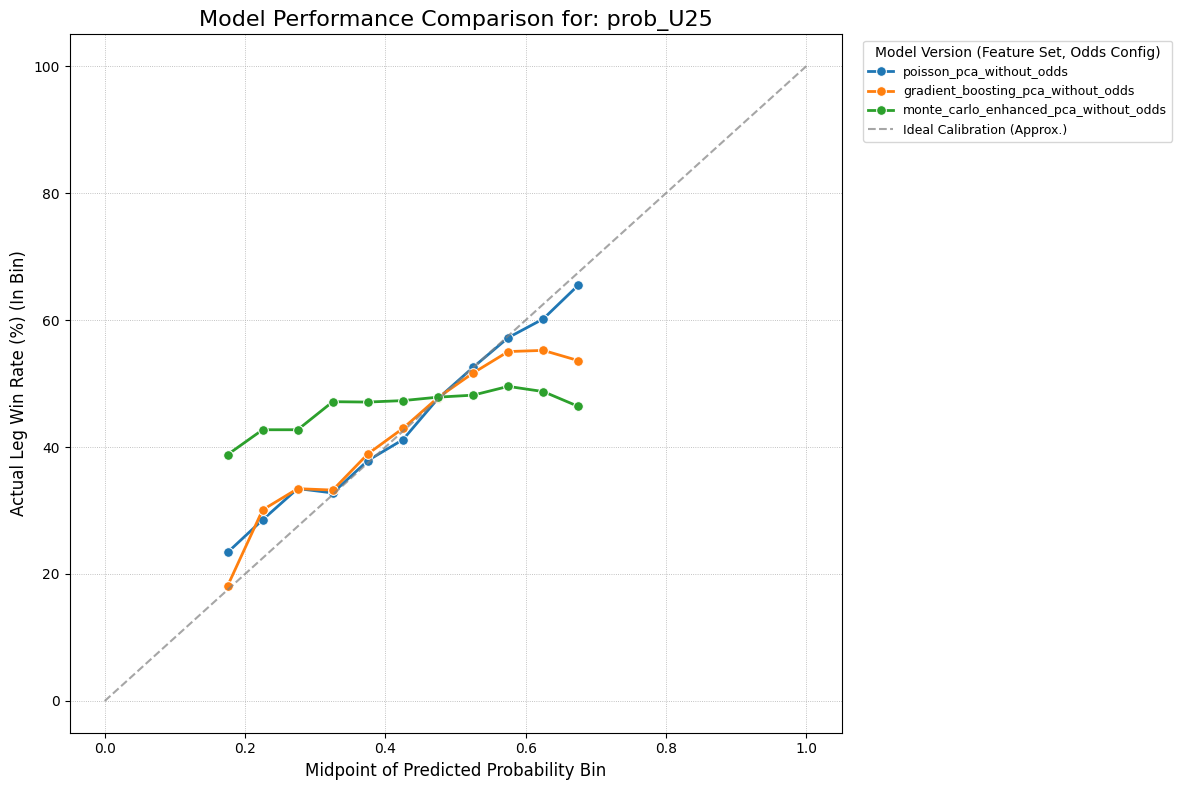

Saved plot: model_perf_comp_BTTS_Y.png


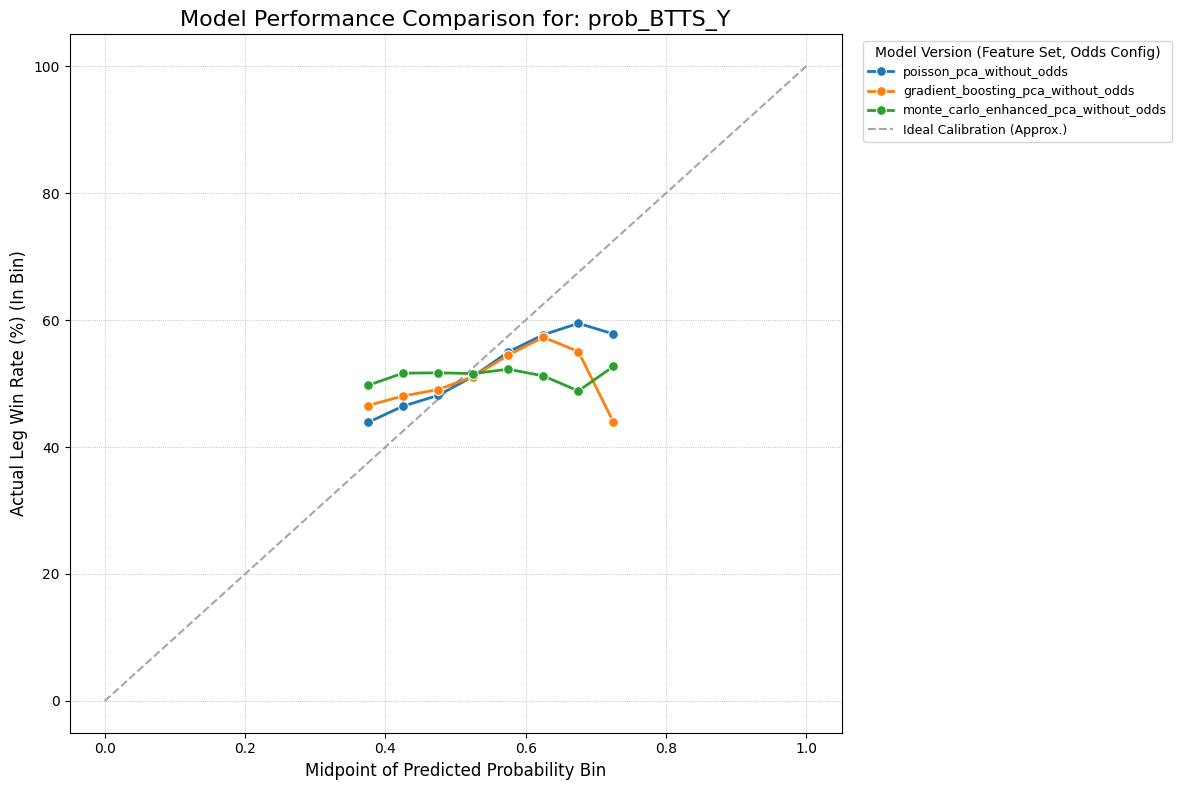

Saved plot: model_perf_comp_1X.png


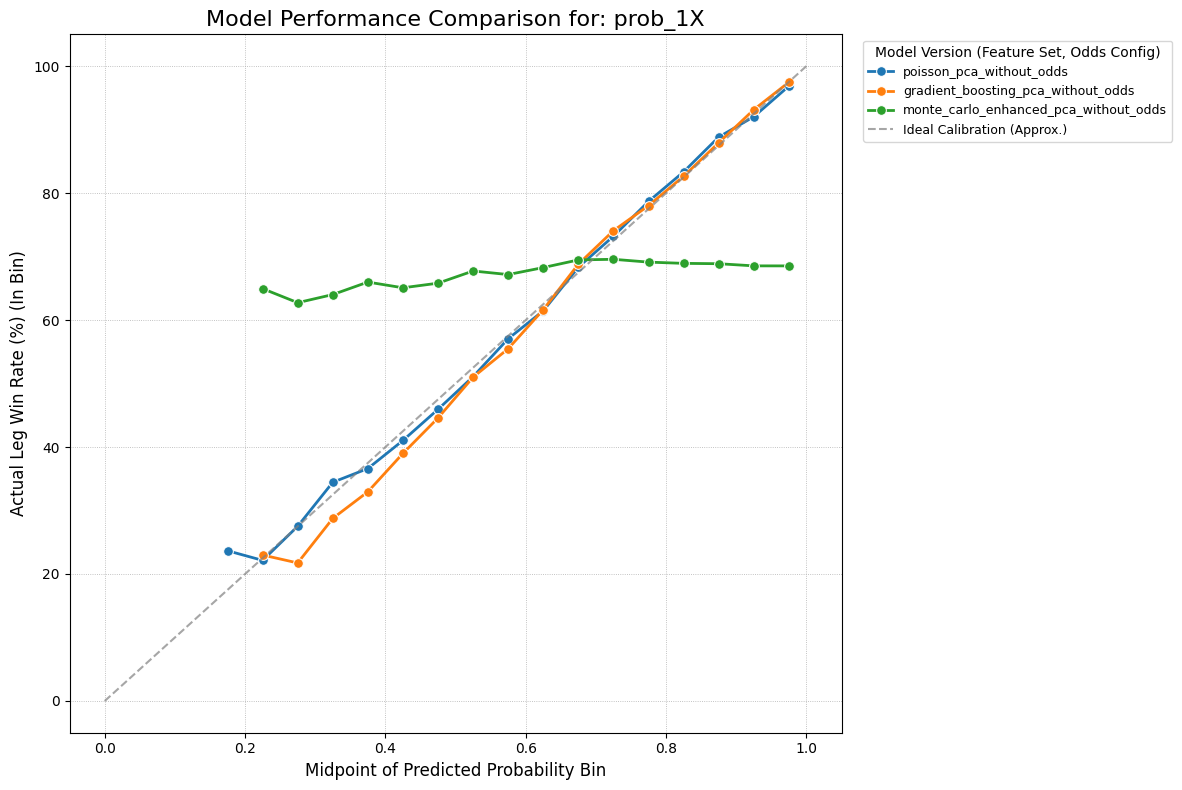

Saved plot: model_perf_comp_12.png


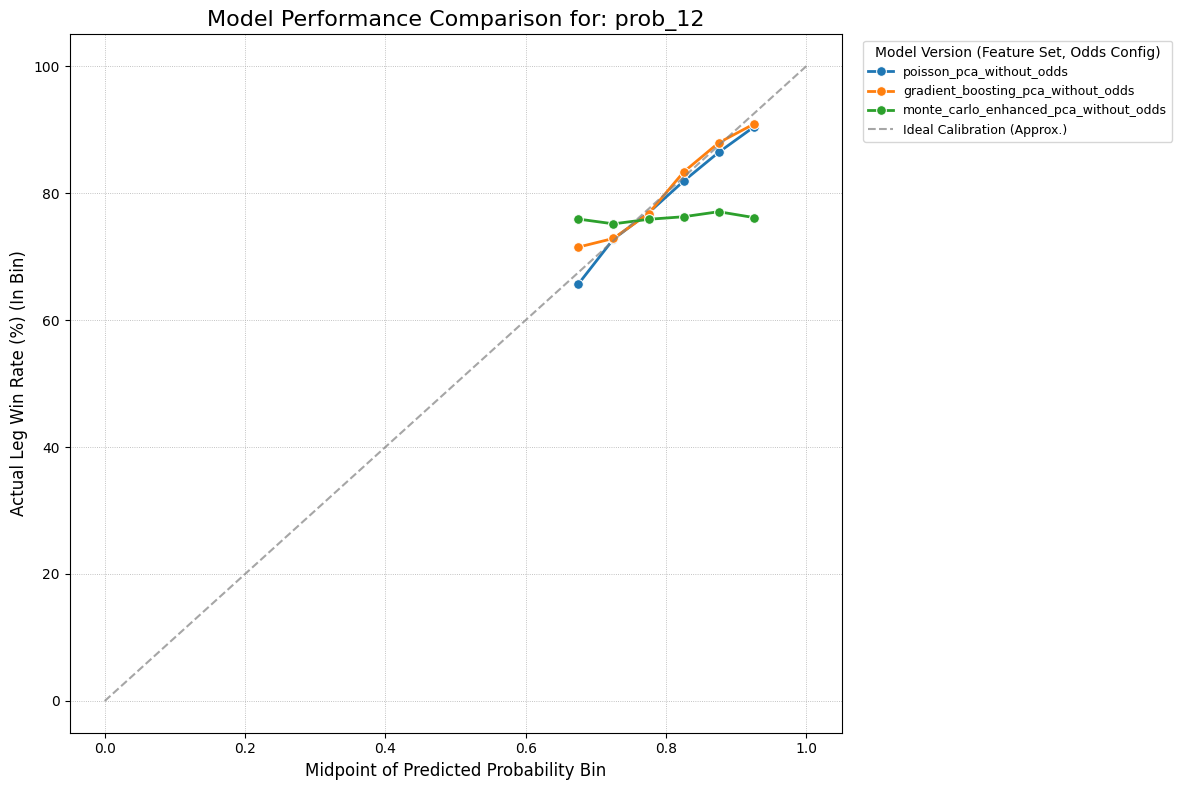

No binned data with sufficient samples for market: prob_U45


--- Performance Comparison at Specific Thresholds (PCA vs. Non-PCA) ---


,market_suffix,model_full_name,feature_type,min_pred_prob_threshold,cumulative_bets_onwards,cumulative_wr_onwards(%)
87,prob_12,gradient_boosting_pca_without_odds,PCA,0.65,219512,75.581289
92,prob_12,poisson_pca_without_odds,PCA,0.70,219254,75.592692
99,prob_12,gradient_boosting_pca_without_odds,PCA,0.75,117702,77.942601
105,prob_12,gradient_boosting_pca_without_odds,PCA,0.80,18272,84.292907
111,prob_12,gradient_boosting_pca_without_odds,PCA,0.85,3622,88.238542
...,...,...,...,...,...,...
546,prob_X2_and_U45,poisson_pca_without_odds,PCA,0.75,110,78.181818
258,prob_goals_3_plus,poisson_pca_without_odds,PCA,0.65,9666,67.846058
265,prob_goals_3_plus,gradient_boosting_pca_without_odds,PCA,0.70,2824,69.050992
271,prob_goals_3_plus,gradient_boosting_pca_without_odds,PCA,0.75,928,74.137931


In [19]:
# %% [markdown]
# ### Z.3. Detailed Comparison: PCA vs. Non-PCA Model Performance Across Probability Bins
#
# We will load the detailed binned performance data (`master_L0_binned_market_performance.csv`)
# generated from both the PCA-based OOF analysis and the Non-PCA-based OOF analysis.
# This allows for:
# 1. Visual comparison of calibration and win rate stability for the same model architecture (e.g., Gradient Boosting)
#    when trained on PCA vs. Non-PCA features for specific markets.
# 2. Quantitative summary to highlight which feature set leads to better performance at various confidence levels.

# %%
# --- Configuration & Constants for this section ---
# Ensure these are defined in your notebook's global setup or here
# MIN_SAMPLES_FOR_BIN = 20 # From your global setup, or redefine if needed for these plots
# COMPARISON_OUTPUT_SUBDIR # Defined in global setup
# CORE_PROBABILITY_SUFFIXES # Defined in global setup

# --- Load Master Binned Performance DataFrames ---
PATH_MASTER_BINNED_PCA_CSV = PCA_OUTPUT_SUBDIR / "master_L0_binned_market_performance.csv"
PATH_MASTER_BINNED_NONPCA_CSV = NONPCA_OUTPUT_SUBDIR / "master_L0_binned_market_performance.csv"

master_binned_perf_pca_df = pd.DataFrame()
if PATH_MASTER_BINNED_PCA_CSV.exists():
    master_binned_perf_pca_df = pd.read_csv(PATH_MASTER_BINNED_PCA_CSV)
    # Ensure 'model' column contains full identifiers like 'gradient_boosting_pca_without_odds'
    print(f"Loaded master binned performance for PCA models: {master_binned_perf_pca_df.shape}")
    # print("PCA Models found:", master_binned_perf_pca_df['model'].unique())
else:
    print(f"CRITICAL WARNING: Master binned PCA performance CSV not found at {PATH_MASTER_BINNED_PCA_CSV}.")

master_binned_perf_nonpca_df = pd.DataFrame()
if PATH_MASTER_BINNED_NONPCA_CSV.exists():
    master_binned_perf_nonpca_df = pd.read_csv(PATH_MASTER_BINNED_NONPCA_CSV)
    # Ensure 'model' column contains full identifiers like 'gradient_boosting_nonpca_without_odds'
    print(f"Loaded master binned performance for NonPCA models: {master_binned_perf_nonpca_df.shape}")
    # print("Non-PCA Models found:", master_binned_perf_nonpca_df['model'].unique())
else:
    print(f"CRITICAL WARNING: Master binned NonPCA performance CSV not found at {PATH_MASTER_BINNED_NONPCA_CSV}.")

# --- Combine for Plotting & Analysis ---
if not master_binned_perf_pca_df.empty and not master_binned_perf_nonpca_df.empty:
    # Add a 'feature_type' column to each before concatenating for clarity in plots and tables
    master_binned_perf_pca_df['feature_type'] = 'PCA'
    master_binned_perf_nonpca_df['feature_type'] = 'NonPCA'
    
    combined_binned_df = pd.concat(
        [master_binned_perf_pca_df, master_binned_perf_nonpca_df],
        ignore_index=True
    )
    print(f"Combined binned performance data shape: {combined_binned_df.shape}")

    # Extract base model type (e.g., 'gradient_boosting', 'poisson') for grouping
    # Assumes model names are like 'gradient_boosting_pca_without_odds' or 'poisson_nonpca_without_odds'
    def extract_base_model(model_name_str):
        if isinstance(model_name_str, str):
            if "gradient_boosting" in model_name_str: return "gradient_boosting"
            if "poisson" in model_name_str: return "poisson"
            if "monte_carlo" in model_name_str: return "monte_carlo_enhanced" # Or just "monte_carlo"
        return "unknown_model"
    combined_binned_df['base_model_type'] = combined_binned_df['model'].apply(extract_base_model)

else:
    print("One or both master binned performance DataFrames are missing. Cannot proceed with Z.3 comparison.")
    combined_binned_df = pd.DataFrame() # Ensure it exists to prevent later errors


# %% [markdown]
# #### Z.3.1. Visual Comparison: Calibration & Stability Plots
# For each key market and base model type (e.g., Gradient Boosting), plot PCA vs. Non-PCA performance.

# %%
if not combined_binned_df.empty:
    # Define key markets and base models you want to compare
    # You can get markets from `final_comparison_best_selections['market_suffix'].unique()` from Z.1
    # or define manually.
    if 'final_comparison_best_selections' in locals() and not final_comparison_best_selections.empty:
         markets_to_plot = sorted(list(final_comparison_best_selections['market_suffix'].unique()))[:7] # Top 7 distinct markets
    else: # Fallback if previous table not generated
        markets_to_plot = ['prob_H', 'prob_O25', 'prob_U25', 'prob_BTTS_Y', 'prob_1X', 'prob_12', 'prob_U45']
        print(f"Warning: `final_comparison_best_selections` not available. Using fallback markets: {markets_to_plot}")

    print(f"\n--- Generating Visual Comparison Plots for markets: {markets_to_plot} ---")

    for market_suffix_viz in markets_to_plot:
        # Filter for the current market and ensure sufficient samples in bins
        market_plot_data = combined_binned_df[
            (combined_binned_df['market_suffix'] == market_suffix_viz) &
            (combined_binned_df['num_bets'] >= MIN_SAMPLES_FOR_BIN)
        ].copy()

        if market_plot_data.empty:
            print(f"No binned data with sufficient samples for market: {market_suffix_viz}")
            continue
        
        # We want to compare PCA vs NonPCA for each base model type (GB, Poisson, MC)
        # The 'model' column should already distinguish them (e.g., 'gradient_boosting_pca_without_odds', 'gradient_boosting_nonpca_without_odds')
        
        # Get all unique model names from the filtered data for this market
        # This avoids the NameError with MODEL_PREFIXES_PCA and MODEL_PREFIXES_NONPCA
        relevant_model_names = market_plot_data['model'].unique().tolist()
        
        # Keep only rows where the model is one of the relevant ones for this market
        # (This step might be redundant since market_plot_data already contains only relevant models)
        plot_data_for_market_and_models = market_plot_data[
            market_plot_data['model'].isin(relevant_model_names)
        ]

        if plot_data_for_market_and_models.empty or plot_data_for_market_and_models['model'].nunique() < 1 :
            print(f"Not enough distinct model data (PCA & NonPCA versions) for {market_suffix_viz}. Skipping plot.")
            continue
            
        plt.figure(figsize=(15, 8))
        sns.lineplot(
            x='prob_bin_mid',
            y='actual_win_rate_pct',
            hue='model', # Use the full model name for hue. It will distinguish PCA/NonPCA if names are unique.
            # style='feature_type', # Optionally, if you want to add another visual distinction
            data=plot_data_for_market_and_models,
            marker='o',
            linewidth=2,
            markersize=7,
            errorbar=None
        )
        
        plt.plot([0, 1], [0, 100], linestyle='--', color='grey', label='Ideal Calibration (Approx.)', alpha=0.7)
        plt.title(f'Model Performance Comparison for: {market_suffix_viz}', fontsize=16)
        plt.xlabel('Midpoint of Predicted Probability Bin', fontsize=12)
        plt.ylabel('Actual Leg Win Rate (%) (In Bin)', fontsize=12)
        plt.legend(title='Model Version (Feature Set, Odds Config)', bbox_to_anchor=(1.02, 1), loc='upper left', title_fontsize='10', fontsize='9')
        plt.ylim(-5, 105)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
        plt.grid(True, which='both', linestyle=':', linewidth=0.6)
        plt.tight_layout(rect=[0, 0, 0.80, 1]) # Adjust rect to ensure legend fits if outside
        
        clean_market_name = market_suffix_viz.replace('prob_', '')
        filename = f"model_perf_comp_{clean_market_name}.png" # New filename
        plt.savefig(COMPARISON_OUTPUT_SUBDIR / filename)
        print(f"Saved plot: {filename}")
        plt.show()
        plt.close()
else:
    print("Combined binned performance data not available for plotting in Section Z.3.1.")

# %% [markdown]
# #### Z.3.2. Quantitative Comparison Table: Best Approach per Market at Key Thresholds
#
# Let's create a table that, for each market, shows which approach (PCA or Non-PCA for its best model) performs better at a few key high-probability thresholds (e.g., for predictions >= 0.70, >= 0.75, >= 0.80).

# %%
if not combined_binned_df.empty:
    # Define key probability thresholds to compare performance AT OR ABOVE
    comparison_thresholds = [0.65, 0.70, 0.75, 0.80, 0.85]
    
    comparison_results = []

    for market_s in combined_binned_df['market_suffix'].unique():
        for threshold_val in comparison_thresholds:
            for feat_type in ['PCA', 'NonPCA']:
                # Select relevant models for this feature type
                models_for_type = combined_binned_df[
                    (combined_binned_df['feature_type'] == feat_type) &
                    (combined_binned_df['market_suffix'] == market_s)
                ]['model'].unique()

                for model_n in models_for_type:
                    # Get data at or above this threshold for this market-model-feature_type
                    onwards_data = combined_binned_df[
                        (combined_binned_df['model'] == model_n) & # Full model name
                        (combined_binned_df['market_suffix'] == market_s) &
                        (combined_binned_df['prob_bin_mid'] >= threshold_val) # Bins starting at or above threshold
                    ]
                    
                    if not onwards_data.empty:
                        cumulative_bets = onwards_data['num_bets'].sum()
                        cumulative_wins = (onwards_data['num_bets'] * onwards_data['actual_win_rate_pct'] / 100.0).sum()
                        
                        if cumulative_bets >= MIN_SAMPLES_FOR_BIN: # Need enough cumulative bets for reliable WR
                            cumulative_wr = (cumulative_wins / cumulative_bets) * 100 if cumulative_bets > 0 else 0
                            comparison_results.append({
                                'market_suffix': market_s,
                                'model_full_name': model_n, # Includes _pca_ or _nonpca_
                                'feature_type': feat_type,
                                'min_pred_prob_threshold': threshold_val,
                                'cumulative_bets_onwards': cumulative_bets,
                                'cumulative_wr_onwards(%)': cumulative_wr
                            })

    if comparison_results:
        threshold_comparison_df = pd.DataFrame(comparison_results)
        print("\n\n--- Performance Comparison at Specific Thresholds (PCA vs. Non-PCA) ---")
        
        # For each market and threshold, find the best feature_type (PCA/NonPCA) by WR, then by bets
        idx_best_at_threshold = threshold_comparison_df.sort_values(
            by=['market_suffix', 'min_pred_prob_threshold', 'cumulative_wr_onwards(%)', 'cumulative_bets_onwards'],
            ascending=[True, True, False, False]
        ).groupby(['market_suffix', 'min_pred_prob_threshold'])['cumulative_wr_onwards(%)'].idxmax()
        
        best_at_threshold_summary_df = threshold_comparison_df.loc[idx_best_at_threshold]
        
        display(HTML("<h4>Best Performing Approach (PCA/NonPCA) at Various Thresholds:</h4>"))
        display(best_at_threshold_summary_df.sort_values(by=['market_suffix', 'min_pred_prob_threshold']))
        best_at_threshold_summary_df.to_csv(COMPARISON_OUTPUT_SUBDIR / "best_pca_vs_nonpca_at_thresholds.csv", index=False)
        
        # Example: Show which feature type is better for 'prob_O25' at >= 0.70 threshold
        # display(best_at_threshold_summary_df[
        #     (best_at_threshold_summary_df['market_suffix'] == 'prob_O25') &
        #     (best_at_threshold_summary_df['min_pred_prob_threshold'] == 0.70)
        # ])
    else:
        print("No data generated for threshold comparison table.")
else:
    print("Combined binned performance data not available for Section Z.3.2.")